In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_csv("Position_Salaries.csv")
data

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
X = data.drop(["Position","Salary"] , axis = 1) 
y = data["Salary"]

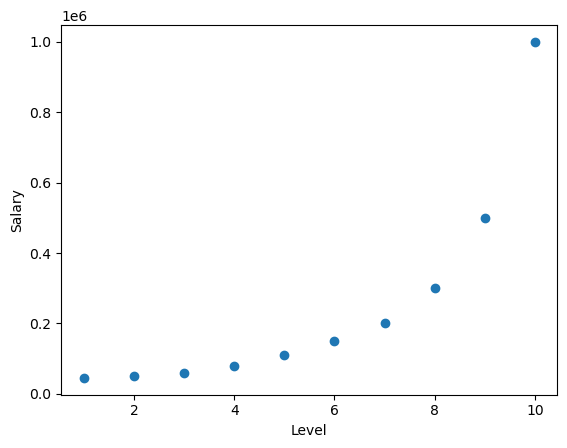

In [4]:
plt.scatter(X, y , label = "Distribution")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

In [5]:
poly = PolynomialFeatures(degree = 3)
X_poly = poly.fit_transform(X)

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X_poly , y, test_size = 0.10 , random_state = 42)

In [7]:
model = LinearRegression()
model = model.fit(X_train , y_train)

In [8]:
y_pred = model.predict(X_test)

In [9]:
MSE = mean_squared_error(y_test , y_pred)
print("MSE = {}".format(MSE))

MSE = 11747926128.92303


In [10]:
model_linear = LinearRegression()
model_linear = model_linear.fit(X, y)

In [11]:
y_pred_linear = model_linear.predict(X)

In [12]:
y_pred_all = model.predict(X_poly)

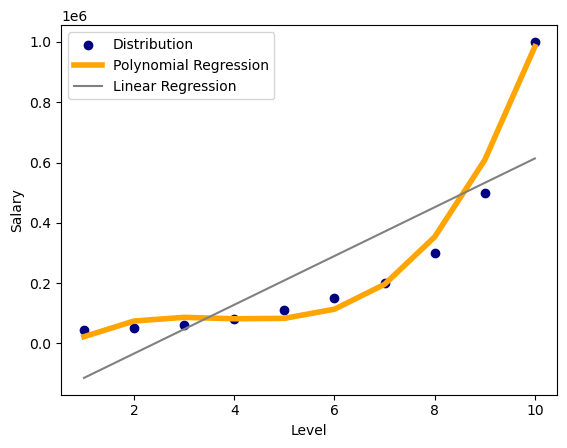

In [13]:
plt.scatter(X, y , label = "Distribution" , color = "navy")
plt.plot(X, y_pred_all, label = "Polynomial Regression" , color = "orange" , linewidth = 4)
plt.plot(X, y_pred_linear, label = "Linear Regression" , color = "gray")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [14]:
# ACTIVITY - 1
X = data[['Level']].values
y = data['Salary'].values

# Polynomial Regression
poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

# Predicting for level = 6.5
level = 6.5
predicted_salary_poly = poly_reg.predict(poly_features.transform([[level]]))[0]
print(f"Polynomial Regression (degree=4) prediction for level 6.5: {predicted_salary_poly:.2f}")

Polynomial Regression (degree=4) prediction for level 6.5: 158862.45


In [15]:
# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Predicting for level = 6.5
predicted_salary_linear = lin_reg.predict([[level]])[0]
print(f"Linear Regression prediction for level 6.5: {predicted_salary_linear:.2f}")


Linear Regression prediction for level 6.5: 330378.79


In [18]:
expected_salary = 175000

print(f"\nExpected (approximate) salary for Level 6.5 based on dataset trend: {expected_salary}")

print(f"Linear Regression prediction: {predicted_salary_linear:.2f}")
print(f"Polynomial Regression prediction: {predicted_salary_poly:.2f}")

# Calculate absolute errors
error_linear = abs(expected_salary - predicted_salary_linear)
error_poly = abs(expected_salary - predicted_salary_poly)

print(f"\nAbsolute Error in Linear Regression: {error_linear:.2f}")
print(f"Absolute Error in Polynomial Regression: {error_poly:.2f}")

# Conclusion
if error_poly < error_linear:
    print("\nPolynomial Regression provides a more accurate prediction for Level 6.5.")
else:
    print("\nLinear Regression seems closer, but this is unlikely for non-linear salary trends.")



Expected (approximate) salary for Level 6.5 based on dataset trend: 175000
Linear Regression prediction: 330378.79
Polynomial Regression prediction: 158862.45

Absolute Error in Linear Regression: 155378.79
Absolute Error in Polynomial Regression: 16137.55

Polynomial Regression provides a more accurate prediction for Level 6.5.


In [23]:
#Activity-2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

dataset = pd.read_csv("insurance_data.csv")
X = dataset[['age']]
y = dataset['bought_insurance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[4 0]
 [0 2]]


In [24]:
age_to_predict = 30
prediction = model.predict([[age_to_predict]])[0]

if prediction == 1:
    print(f"A person aged {age_to_predict} is predicted to BUY insurance.")
else:
    print(f"A person aged {age_to_predict} is predicted to NOT buy insurance.")


A person aged 30 is predicted to NOT buy insurance.


C:\Users\t4she\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Generate range of age values
age_range = np.arange(18, 65).reshape(-1, 1)
probabilities = model.predict_proba(age_range)[:, 1]

# Plot
plt.scatter(df['age'], df['bought_insurance'], color='red', label='Data')
plt.plot(age_range, probabilities, color='blue', label='Logistic Curve')
plt.xlabel('Age')
plt.ylabel('Probability of Buying Insurance')
plt.title('Insurance Buying Probability vs Age')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\t4she\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


NameError: name 'df' is not defined